# **Assignment 2**
# **Numerical Solution of the One-Dimensional Poisson's Equation with the Finite-Difference Method**
**Course:** Numerical Analysis For PDE's (WI3730TU)  
**Instructions:** Complete the mathematical derivations in the Markdown cells and the numerical implementation in the Python cells provided. Show all intermediate steps clearly using $\LaTeX$ notation.


## **Problem Statement**
Consider the boundary-value problem

$$
-\frac{d^2u_i}{dx^2}=f_i,\qquad x\in(0,3),
$$

with

$$
u_i(0)=1,\qquad u_i(3)=1,\qquad i=1,2,
$$

and source functions

$$
f_1(x)=3x-2,\qquad
f_2(x)=x^2+3x-2,\qquad x\in[0,3].
$$


### **Question 1: Exact Solutions**
Find the exact solutions $u_1^{\mathrm{ex}}(x)$ and $u_2^{\mathrm{ex}}(x)$ corresponding to $f_1(x)$ and $f_2(x)$.

*Type your derivation below:*


For $f_1$,

$$ u_1''(x)=-(3x-2) = - 3x+2 $$

Integrating twice gives

$$ u_1'(x)=-\frac{3}{2}x^2+2x+C_1 $$
$$u_1(x)=-\frac12x^3+x^2+C_1x+C_2$$

Using $u_1(0)=1$ gives $C_2=1$. Using $u_1(3)=1$ gives

$$-\frac12(3)^3+(3)^2+3C_1+1=1 $$

hence $C_1=\frac32.$ Therefore,

$$ u_1^{ex}(x) = 1+\frac32x+x^2-\frac12x^3  $$

For the second source function,

$$ u_2''(x)=-(x^2+3x-2)=-x^2-3x+2 $$

Integrating twice gives

$$ u_2'(x) = -\frac13x^3-\frac32x^2+2x+C_1 $$
$$ u_2(x) = -\frac1{12}x^4-\frac12x^3+x^2+C_1x+C_2 $$

Using $u_2(0)=1$ gives $C_2=1$. Using $u_2(3)=1$ gives

$$ -\frac{81}{12}-\frac{27}{2}+9+3C_1+1=1, $$

and therefefore $C_1=\frac{15}{4}$.

Hence,

$$u_2^{ex}(x) = 1+\frac{15}{4}x+x^2-\frac12x^3-\frac1{12}x^4 $$


### **Question 2: Finite-Difference Discretization**
Discretize the problem using the Finite-Difference Method on a uniform grid obtained by dividing $[0,3]$ into $n=5$ equal sub-intervals.

**(a)** Determine the step size $h$, the number of internal and boundary points, and the number of unknowns.  

**(b)** Write the $O(h^2)$ finite-difference approximation of the negative second derivative, including the explicit remainder term.  

**(c)** Write all discrete FD equations and compute the numerical constants explicitly.  

**(d)** Write the system matrix $A$ and the right-hand-side vectors for both source functions.  

**(e)** Compute the theoretical eigenvalues of $A$.  

**(f)** Compute the first four eigenvalues of the continuous negative second-derivative operator.

*Type your derivation below:*


(a) For $n=5$ subintervals on $[0,3]$, $ h=\frac{3-0}{5}=\frac35=0.6. $
The grid contains $n+1=6$ points, $ x_0=0, x_1=0.6,x_2=1.2, x_3=1.8,x_4=2.4,x_5=3. $

There are two boundary points, $x_0$ and $x_5$, and four internal points. Since the boundary values are already known, the problem has four unknowns, $ u_1, u_2, u_3, u_4. $

(b) For a uniform grid, the central difference approximation of the negative second derivative is

$$
-\frac{d^2u}{dx^2}(x_j)
=
\frac{-u_{j+1}+2u_j-u_{j-1}}{h^2}
+
\frac{h^2}{12}u^{(4)}(x_j)
+
O(h^4)
$$

$$
-\frac{d^2u}{dx^2}(x_j)
=
\frac{-u_{j+1}+2u_j-u_{j-1}}{h^2}
+
O(h^2)
$$

(c) Since $ \frac{1}{h^2} = \frac{1}{0.36} = \frac{25}{9} \approx 2.7778, $ the four discrete equations are, with the boundary terms rearranged on the right side such that only unkowns remain on the left side,

$$
\frac{25}{9}(2u_1-u_2)=f(x_1)+\frac{25}{9},
$$

$$
\frac{25}{9}(-u_1+2u_2-u_3)=f(x_2),
$$

$$
\frac{25}{9}(-u_2+2u_3-u_4)=f(x_3),
$$

$$
\frac{25}{9}(-u_3+2u_4)=f(x_4)+\frac{25}{9}.
$$

For $f_1(x)=3x-2$, $ f_1(x_1)=-0.2, f_1(x_2)=1.6, f_1(x_3)=3.4, f_1(x_4)=5.2 $.

Thus,

$$
5.556u_1-2.778u_2=2.578,
$$

$$
-2.778u_1+5.556u_2-2.778u_3=1.6,
$$

$$
-2.78u_2+5.556u_3-2.778u_4=3.4,
$$

$$
-2.78u_3+5.556u_4=7.978.
$$

For $f_2(x)=x^2+3x-2$, $ f_2(x_1)=0.16,f_2(x_2)=3.04, f_2(x_3)=6.64,f_2(x_4)=10.96. $

Thus,

$$
5.5556u_1-2.7778u_2=2.9378,
$$

$$
-2.78u_1+5.56u_2-2.778u_3=3.04,
$$

$$
-2.778u_2+5.556u_3-2.778u_4=6.64,
$$

$$
-2.778u_3+5.556u_4=13.7378.
$$

(d) The system matrix is

$$ A= \frac{25}{9} \begin{pmatrix}
2 & -1 & 0 & 0\\
-1 & 2 & -1 & 0\\
0 & -1 & 2 & -1\\
0 & 0 & -1 & 2
\end{pmatrix}  $$

and the two boundary right-hand-side vectors are

$$

\mathbf f_1=
\begin{pmatrix}
2.57777778\\
1.6\\
3.4\\
7.97777778
\end{pmatrix},
\mathbf f_2=
\begin{pmatrix}
2.93777778\\
3.04\\
6.64\\
13.73777778
\end{pmatrix}
$$

(e)-(f) For a grid with $n$ sub-intervals, the theoretical eigenvalues of the discrete negative Laplacian are

$$
\lambda_k
=
\frac{4}{h^2}
\sin^2\left(\frac{\pi k}{2n}\right),
\qquad
k=1,\ldots,n-1.
$$

For $n=5$ and $h=0.6$,

| $k$ | Discrete $\lambda_k$ | Continuous $\widetilde{\lambda}_k=(\pi k/3)^2$ |
|---:|---:|---:|
| 1 | $1.06101670$ | $1.09662271$ |
| 2 | $3.83879448$ | $4.38649084$ |
| 3 | $7.27231664$ | $9.86960440$ |
| 4 | $10.05009441$ | $17.54596338$ |

The discrete eigenvalues approach the continuous eigenvalues as $h\to0$.


### **Question 3: Python Environment**
Check that NumPy and Matplotlib are available.

*Run the code below:*


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Python environment is ready.")


NumPy version: 2.4.6
Python environment is ready.


### **Question 4: Uniform Grid, Source Functions, and Exact Solutions**
Construct a uniform grid using `np.linspace()`. Define the source functions and exact solutions with Python functions. Plot $f_1$, $f_2$, $u_1^{\mathrm{ex}}$, and $u_2^{\mathrm{ex}}$ using LaTeX labels. Make sure the code works for any $n$.

*Run the code below:*


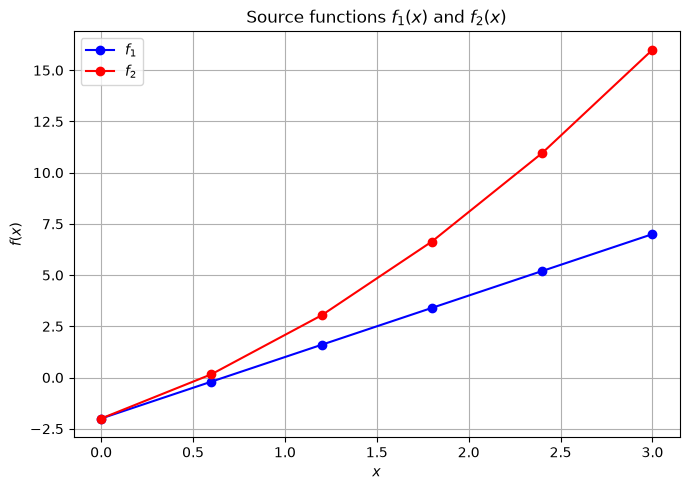

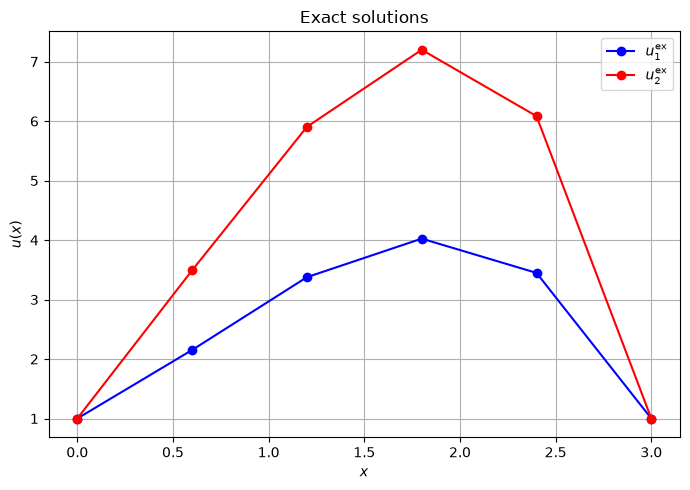

In [6]:
# Uniform grid
n = 5
a = 0.0
b = 3.0
h = (b - a) / n
xgrid = np.linspace(a, b, n + 1)

# Source functions
def func1(x):
    return 3*x - 2

def func2(x):
    return x**2 + 3*x - 2

# Exact solutions
def u1_exact(x):
    return 1 + (3/2)*x + x**2 - (1/2)*x**3

def u2_exact(x):
    return 1 + (15/4)*x + x**2 - (1/2)*x**3 - (1/12)*x**4

# Grid values
f1 = func1(xgrid)
f2 = func2(xgrid)

u1ex = u1_exact(xgrid)
u2ex = u2_exact(xgrid)

# Source-function plot
plt.figure(figsize=(7, 5))
plt.plot(xgrid, f1, "bo-", label=r"$f_1$")
plt.plot(xgrid, f2, "ro-", label=r"$f_2$")
plt.legend()
plt.title(r"Source functions $f_1(x)$ and $f_2(x)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.grid(True)
plt.tight_layout()
plt.savefig("assignment2_source_functions.pdf")
plt.show()

# Exact-solution plot
plt.figure(figsize=(7, 5))
plt.plot(xgrid, u1ex, "bo-", label=r"$u_1^{\mathrm{ex}}$")
plt.plot(xgrid, u2ex, "ro-", label=r"$u_2^{\mathrm{ex}}$")
plt.legend()
plt.title("Exact solutions")
plt.xlabel(r"$x$")
plt.ylabel(r"$u(x)$")
plt.grid(True)
plt.tight_layout()
plt.savefig("assignment2_exact_solutions.pdf")
plt.show()


### **Question 5: Assemble the Finite-Difference Laplacian Matrix**
Construct the $(n-1)\times(n-1)$ negative finite-difference Laplacian matrix using `np.diag()`. Visualize its structure using `plt.spy()`, and compute its eigenvalues numerically for $n=5$.

*Run the code below:*


A =
[[ 5.55555556 -2.77777778  0.          0.        ]
 [-2.77777778  5.55555556 -2.77777778  0.        ]
 [ 0.         -2.77777778  5.55555556 -2.77777778]
 [ 0.          0.         -2.77777778  5.55555556]]

Shape of A: (4, 4)


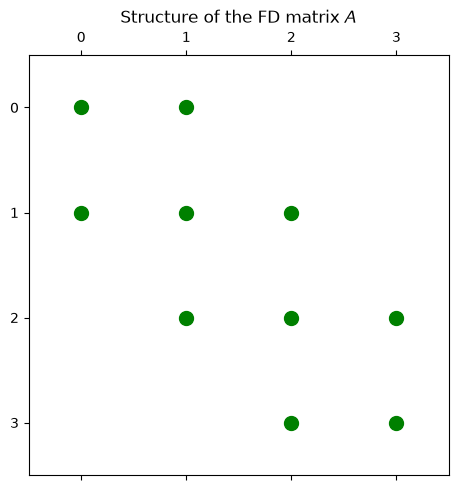


 k    theoretical A       continuous operator     numerical A
 1       1.06101670           1.09662271       1.06101670
 2       3.83879448           4.38649084       3.83879448
 3       7.27231664           9.86960440       7.27231664
 4      10.05009441          17.54596338      10.05009441


In [4]:
# Number of internal unknowns
m = n - 1

# Three diagonals of the negative 1D FD Laplacian
main_diagonal = 2*np.ones(m)
off_diagonal = -np.ones(m - 1)

A = (
    np.diag(main_diagonal)
    + np.diag(off_diagonal, k=1)
    + np.diag(off_diagonal, k=-1)
) / h**2

print("A =")
print(A)
print("\nShape of A:", A.shape)

# Matrix structure
plt.figure(figsize=(5, 5))
plt.spy(A, marker="o", color="green", markersize=10)
plt.title(r"Structure of the FD matrix $A$")
plt.tight_layout()
plt.savefig("assignment2_matrix_spy.pdf")
plt.show()

# Numerical eigenvalues
eigenvalues_numeric = np.sort(np.linalg.eigvals(A).real)

# Theoretical discrete eigenvalues
k = np.arange(1, n)
eigenvalues_theoretical = (4/h**2) * np.sin(np.pi*k/(2*n))**2

# Continuous operator eigenvalues
eigenvalues_continuous = (np.pi*k/(b-a))**2

print("\n k    theoretical A       continuous operator     numerical A")
for i in range(m):
    print(
        f"{i+1:2d}   "
        f"{eigenvalues_theoretical[i]:14.8f}   "
        f"{eigenvalues_continuous[i]:18.8f}   "
        f"{eigenvalues_numeric[i]:14.8f}"
    )


### **Question 6: Solve the Linear Algebraic Problems**
Construct the boundary-adjusted right-hand-side vectors and solve

$$
A\mathbf u_1=\mathbf f_1,
\qquad
A\mathbf u_2=\mathbf f_2.
$$

Append the two boundary values and compare the numerical solutions with the exact solutions.

*Run the code below:*


f1rhs = [2.57777778 1.6        3.4        7.97777778]
f2rhs = [ 2.93777778  3.04        6.64       13.73777778]
u1 = [1.    2.152 3.376 4.024 3.448 1.   ]
u2 = [1.     3.448  5.8384 7.1344 6.04   1.    ]


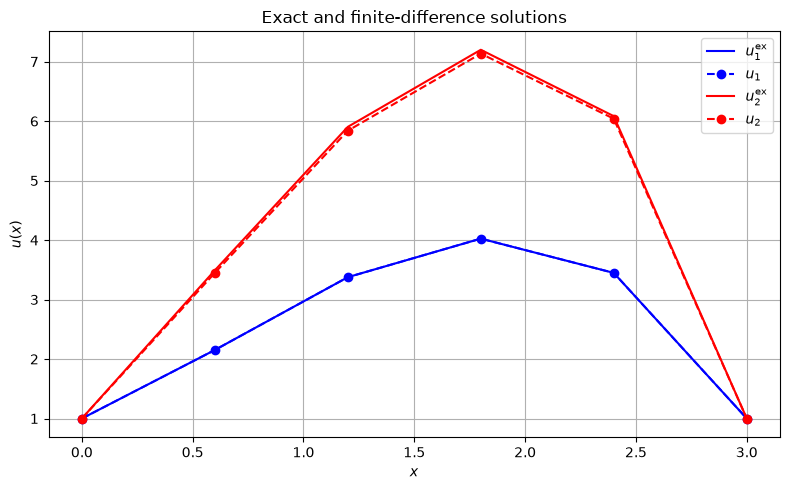

In [5]:
# Interior source values
f1rhs = f1[1:-1].copy()
f2rhs = f2[1:-1].copy()

# Dirichlet boundary conditions u(0) = u(3) = 1
left_bc = 1.0
right_bc = 1.0

f1rhs[0] += left_bc / h**2
f1rhs[-1] += right_bc / h**2

f2rhs[0] += left_bc / h**2
f2rhs[-1] += right_bc / h**2

# Solve the linear systems
u1_internal = np.linalg.solve(A, f1rhs)
u2_internal = np.linalg.solve(A, f2rhs)

# Append boundary values
u1 = np.concatenate(([left_bc], u1_internal, [right_bc]))
u2 = np.concatenate(([left_bc], u2_internal, [right_bc]))

print("f1rhs =", f1rhs)
print("f2rhs =", f2rhs)
print("u1 =", u1)
print("u2 =", u2)

# Exact and numerical solutions
plt.figure(figsize=(8, 5))
plt.plot(xgrid, u1ex, "b-", label=r"$u_1^{\mathrm{ex}}$")
plt.plot(xgrid, u1, "b--o", label=r"$u_1$")
plt.plot(xgrid, u2ex, "r-", label=r"$u_2^{\mathrm{ex}}$")
plt.plot(xgrid, u2, "r--o", label=r"$u_2$")
plt.legend()
plt.title("Exact and finite-difference solutions")
plt.xlabel(r"$x$")
plt.ylabel(r"$u(x)$")
plt.grid(True)
plt.tight_layout()
plt.savefig("assignment2_exact_vs_fdm.pdf")
plt.show()


### **Question 7: Error and Convergence Analysis**
**(a)** Compute the global error between the numerical and exact solutions for $n=5$ and explain the result.  

**(b)** Study the convergence rate by changing $n$ and displaying the logarithm of the global error as a function of $n$.

In this notebook, the global error is taken to be the maximum nodal error,

$$
E_\infty
=
\max_j
\left|
u_j-u^{\mathrm{ex}}(x_j)
\right|.
$$

*Run the code below:*


In [ ]:
# Global errors for n = 5
error1 = np.max(np.abs(u1 - u1ex))
error2 = np.max(np.abs(u2 - u2ex))

print(f"Global error for u1, n=5: {error1:.16e}")
print(f"Global error for u2, n=5: {error2:.16e}")


For $u_1^{\mathrm{ex}}$, the exact solution is a cubic polynomial. The centered second-difference formula differentiates cubic polynomials exactly because the fourth derivative is zero. Therefore the FDM solution agrees with the exact grid values up to floating-point round-off error.

For $u_2^{\mathrm{ex}}$, the exact solution is quartic and

$$
\left(u_2^{\mathrm{ex}}\right)^{(4)}=-2\neq0.
$$

The $O(h^2)$ truncation-error term therefore remains, so the global error is nonzero and should decrease approximately proportionally to $h^2$, or equivalently to $n^{-2}$.


In [ ]:
def solve_fdm(n):
    a = 0.0
    b = 3.0
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)

    f1 = func1(x)
    f2 = func2(x)

    m = n - 1
    main = 2*np.ones(m)
    off = -np.ones(m - 1)

    A = (
        np.diag(main)
        + np.diag(off, k=1)
        + np.diag(off, k=-1)
    ) / h**2

    rhs1 = f1[1:-1].copy()
    rhs2 = f2[1:-1].copy()

    rhs1[0] += 1/h**2
    rhs1[-1] += 1/h**2

    rhs2[0] += 1/h**2
    rhs2[-1] += 1/h**2

    u1_int = np.linalg.solve(A, rhs1)
    u2_int = np.linalg.solve(A, rhs2)

    u1_num = np.concatenate(([1.0], u1_int, [1.0]))
    u2_num = np.concatenate(([1.0], u2_int, [1.0]))

    u1_ex = u1_exact(x)
    u2_ex = u2_exact(x)

    E1 = np.max(np.abs(u1_num - u1_ex))
    E2 = np.max(np.abs(u2_num - u2_ex))

    return h, E1, E2


n_values = np.array([5, 10, 20, 40, 80])
h_values = []
errors1 = []
errors2 = []

for n_i in n_values:
    h_i, E1_i, E2_i = solve_fdm(n_i)
    h_values.append(h_i)
    errors1.append(E1_i)
    errors2.append(E2_i)

h_values = np.array(h_values)
errors1 = np.array(errors1)
errors2 = np.array(errors2)

print(" n        h              E1                  E2")
for n_i, h_i, E1_i, E2_i in zip(n_values, h_values, errors1, errors2):
    print(f"{n_i:3d}   {h_i:8.5f}   {E1_i:16.8e}   {E2_i:16.8e}")

# Experimental order for u2
orders2 = np.log(errors2[:-1] / errors2[1:]) / np.log(2)

print("\nExperimental convergence orders for u2:")
for i, p in enumerate(orders2):
    print(f"n={n_values[i]:3d} -> n={n_values[i+1]:3d}: p = {p:.6f}")

# Logarithm of global error as a function of n
plt.figure(figsize=(7, 5))
plt.plot(n_values, np.log(errors2), "o-")
plt.title(r"Logarithm of the global error for $u_2$")
plt.xlabel(r"$n$")
plt.ylabel(r"$\log(E_\infty)$")
plt.grid(True)
plt.tight_layout()
plt.savefig("assignment2_convergence.pdf")
plt.show()

# Log-log fit: E approximately C n^p
fit = np.polyfit(np.log(n_values), np.log(errors2), 1)
print(f"Log-log fitted slope for u2: {fit[0]:.6f}")


The convergence study shows that the error of $u_2$ behaves as

$$
E_\infty \propto h^2.
$$

Since $h=3/n$,

$$
E_\infty \propto n^{-2}.
$$

Therefore, when the number of sub-intervals is doubled, the global error is reduced by approximately a factor of four. The experimental convergence order approaches

$$
\boxed{p=2},
$$

which agrees with the second-order central finite-difference approximation.

The $u_1$ error stays near machine precision instead of following the $O(h^2)$ curve because the centered second difference is exact for its cubic exact solution.
